In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data = pd.read_csv("Dataset/1.creditcard.csv")
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [2]:
X = data.drop(columns=['Class'])
y = data['Class']
print(y.value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


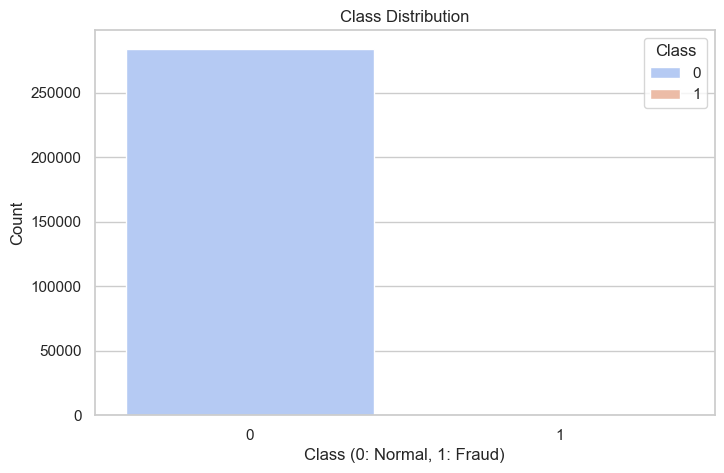

In [3]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

plt.figure(figsize=(8, 5))
sns.countplot(x=y, hue=y, palette="coolwarm")
plt.title("Class Distribution")
plt.xlabel("Class (0: Normal, 1: Fraud)")
plt.ylabel("Count")
plt.show()

In [4]:
base_estimator = DecisionTreeClassifier(max_depth=1)
adaboost = AdaBoostClassifier(estimator=base_estimator, n_estimators=50, learning_rate=1.0, random_state=42)

adaboost.fit(X_train, y_train)

y_pred = adaboost.predict(X_test)
y_pred_proba = adaboost.predict_proba(X_test)
y_pred_proba

array([[0.70529031, 0.29470969],
       [0.69256122, 0.30743878],
       [0.66518594, 0.33481406],
       ...,
       [0.79061916, 0.20938084],
       [0.68289881, 0.31710119],
       [0.73919229, 0.26080771]], shape=(85443, 2))

In [5]:
y_pred_proba = y_pred_proba[:, 1]
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     85295
           1       0.74      0.68      0.70       148

    accuracy                           1.00     85443
   macro avg       0.87      0.84      0.85     85443
weighted avg       1.00      1.00      1.00     85443



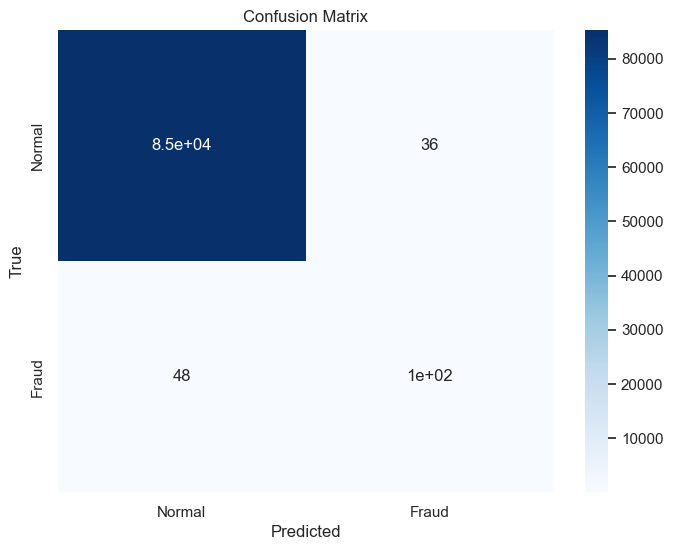

In [6]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", xticklabels=["Normal", "Fraud"], yticklabels=["Normal", "Fraud"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

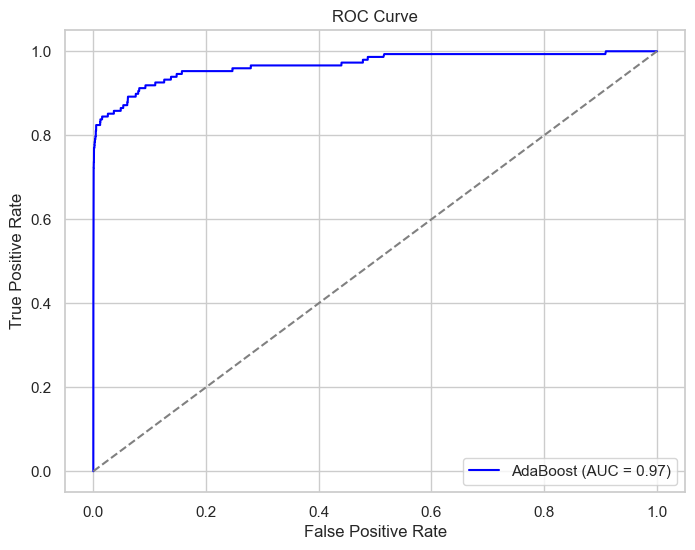

In [7]:
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'AdaBoost (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

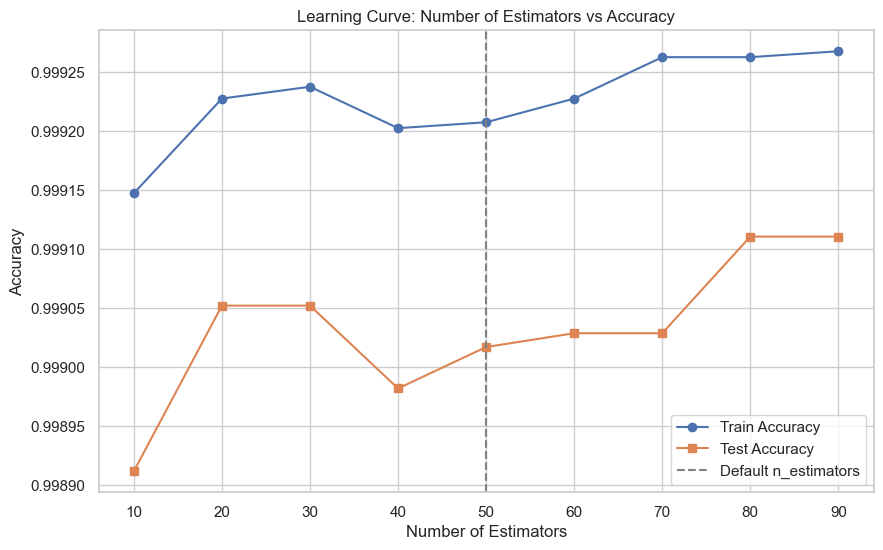

In [8]:
n_estimators_range = range(10, 100, 10)
train_scores, test_scores = [], []

for n_estimators in n_estimators_range:
    model = AdaBoostClassifier(estimator=base_estimator, n_estimators=n_estimators, random_state=42)
    model.fit(X_train, y_train)
    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

plt.figure(figsize=(10, 6))
plt.plot(n_estimators_range, train_scores, label="Train Accuracy", marker='o')
plt.plot(n_estimators_range, test_scores, label="Test Accuracy", marker='s')
plt.axvline(x=50, color="gray", linestyle="--", label="Default n_estimators")
plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Learning Curve: Number of Estimators vs Accuracy")
plt.legend(loc="best")
plt.show()

Fitting 4 folds for each of 4 candidates, totalling 16 fits
[CV] END ..........estimator__max_depth=1, learning_rate=0.5; total time=  20.1s
[CV] END ..........estimator__max_depth=1, learning_rate=0.5; total time=  20.3s
[CV] END ..........estimator__max_depth=1, learning_rate=0.5; total time=  20.6s
[CV] END ..........estimator__max_depth=1, learning_rate=0.5; total time=  20.2s
[CV] END ..........estimator__max_depth=1, learning_rate=1.0; total time=  20.5s
[CV] END ..........estimator__max_depth=1, learning_rate=1.0; total time=  20.4s
[CV] END ..........estimator__max_depth=1, learning_rate=1.0; total time=  20.3s
[CV] END ..........estimator__max_depth=1, learning_rate=1.0; total time=  20.4s
[CV] END ..........estimator__max_depth=2, learning_rate=0.5; total time=  38.0s
[CV] END ..........estimator__max_depth=2, learning_rate=0.5; total time=  40.6s
[CV] END ..........estimator__max_depth=2, learning_rate=0.5; total time=  38.1s
[CV] END ..........estimator__max_depth=2, learni

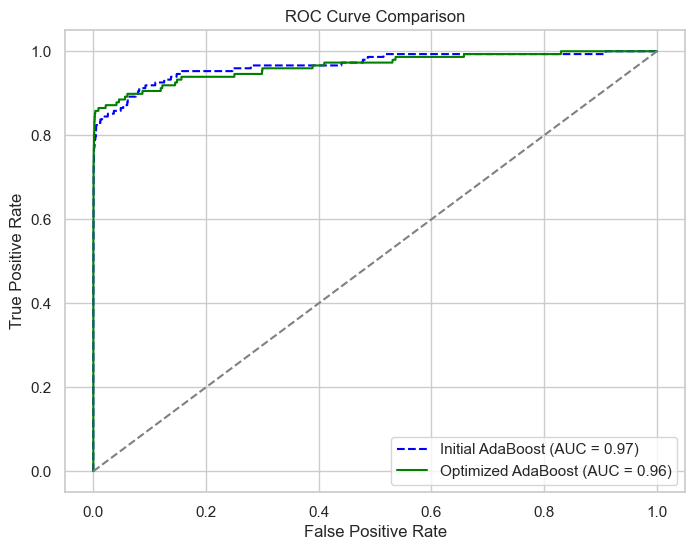

In [13]:
# 网格搜索优化 我这里删了不少参数 n_estimators
param_grid = {
    "learning_rate": [0.5, 1.0],
    "estimator__max_depth": [1, 2]
}

grid_search = GridSearchCV(AdaBoostClassifier(estimator=DecisionTreeClassifier(), random_state=42),
                           param_grid, cv=4, scoring="roc_auc", verbose=2)
grid_search.fit(X_train, y_train)

# 输出最优参数
best_params = grid_search.best_params_
print("\n最优参数：\n", best_params)

# 使用最优参数训练模型
optimized_model = grid_search.best_estimator_
optimized_model.fit(X_train, y_train)

# 评估优化后的模型
optimized_y_pred = optimized_model.predict(X_test)
optimized_y_pred_proba = optimized_model.predict_proba(X_test)[:, 1]

print("\n优化后模型分类报告：\n")
print(classification_report(y_test, optimized_y_pred))

# 优化后ROC曲线
fpr_opt, tpr_opt, _ = roc_curve(y_test, optimized_y_pred_proba)
roc_auc_opt = auc(fpr_opt, tpr_opt)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', linestyle='--', label=f'Initial AdaBoost (AUC = {roc_auc:.2f})')
plt.plot(fpr_opt, tpr_opt, color='green', label=f'Optimized AdaBoost (AUC = {roc_auc_opt:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## AdaBoost 的适用场景与替代选择

### 何时选择 AdaBoost

- **弱分类器表现一般**：如果弱分类器单独表现不好，且分类边界需要逐步逼近，AdaBoost 是优选。
- **需要解释性**：AdaBoost 提供了每个弱分类器的权重，便于分析模型的重要特性。
- **中小型数据集**：数据量不大且噪声较少时，AdaBoost 能快速收敛且效果显著。

### 何时选择其他算法

- **数据有较多噪声时**（选择 随机森林 或 GBDT）：随机森林通过随机采样降低噪声影响，GBDT 有正则化机制控制过拟合。
- **特征复杂且数量较多时**（选择 GBDT 或 深度学习）：GBDT 更擅长捕捉特征间复杂的交互关系，深度学习适合大规模高维数据。
- **需要更高的鲁棒性时**（选择 随机森林）：随机森林无需动态调整样本权重，对噪声和异常值表现更稳定。
- **类别严重不平衡时**（选择 改进型方法，如 SMOTE 搭配 GBDT）：AdaBoost 在不平衡数据上可能偏向少数类，而 GBDT 可以通过目标函数优化类别权重。